In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [2]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
from IPython.display import display

In [3]:
X_train95 = pd.read_csv('./data/processed/X_train95.csv')
X_test95 = pd.read_csv('./data/processed/X_test95.csv')

X_train50 = pd.read_csv('./data/processed/X_train50.csv')
X_test50 = pd.read_csv('./data/processed/X_test50.csv')

X_train0 = pd.read_csv('./data/processed/X_train0.csv')
X_test0 = pd.read_csv('./data/processed/X_test0.csv')

Y_train = pd.read_csv('./data/processed/Y_train.csv').values.ravel()
Y_test = pd.read_csv('./data/processed/Y_test.csv').values.ravel()

print(X_train95.shape, X_train0.shape, Y_train.shape, X_test95.shape, X_train0.shape, Y_test.shape)

(2520, 75) (2520, 130) (2520,) (1080, 75) (2520, 130) (1080,)


In [45]:
def grid_search(estimator, param_grid, cv, scoring, X, Y, randomized=False):
    if randomized:
        gs = RandomizedSearchCV(estimator=estimator, param_distributions=rf_params, n_iter=50, cv=cv, scoring=scoring, random_state=42, n_jobs=-1)
    else:
        gs = GridSearchCV(estimator=estimator, param_grid=param_grid, cv=cv, scoring=scoring)
    gs.fit(X, Y)

    print(f'Best params: {gs.best_params_}')
    print(f'F1 score: {gs.best_score_}')

    display(pd.DataFrame(gs.cv_results_)[['mean_test_score', 'params']].sort_values(by='mean_test_score', ascending=False).head(5))

    return gs.best_params_

In [5]:
def train_and_evaluate(classifier, best_params, X_train, Y_train, X_test, Y_test):
    model = classifier(**best_params)
    model.fit(X_train, Y_train)

    preds = model.predict(X_test)

    print(f'Accuracy: {accuracy_score(Y_test, preds)}')
    print(f'F1 score: {f1_score(Y_test, preds)}')
    print(f'Precision: {precision_score(Y_test, preds)}')
    print(f'Recall: {recall_score(Y_test, preds)}')
    ConfusionMatrixDisplay.from_predictions(Y_test, preds)
    plt.show()

# **Ridge Classifier**

In [6]:
rgc_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'class_weight': [None, 'balanced'],
}

### PCA with 95% explainec variance

In [7]:
rgc95_best_params = grid_search(estimator=RidgeClassifier(), param_grid=rgc_params, cv=5, scoring='f1', X=X_train95, Y=Y_train)

Best params: {'alpha': 1000, 'class_weight': 'balanced'}
F1 score: 0.48312953116562574


,mean_test_score,params
13,0.483130,"{'alpha': 1000, 'class_weight': 'balanced'}"
11,0.472573,"{'alpha': 100, 'class_weight': 'balanced'}"
9,0.470350,"{'alpha': 10, 'class_weight': 'balanced'}"
5,0.469021,"{'alpha': 0.1, 'class_weight': 'balanced'}"
1,0.469021,"{'alpha': 0.001, 'class_weight': 'balanced'}"


Accuracy: 0.762962962962963
F1 score: 0.4838709677419355
Precision: 0.34782608695652173
Recall: 0.7947019867549668


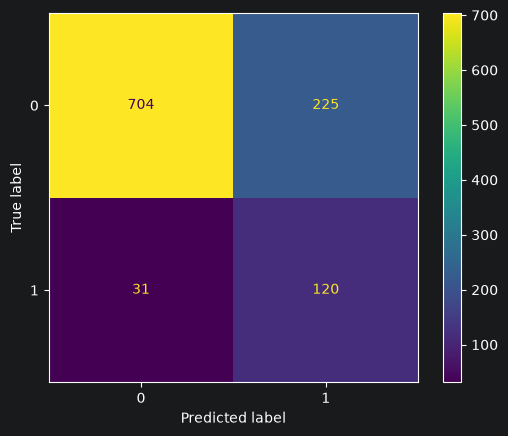

In [8]:
train_and_evaluate(classifier=RidgeClassifier, best_params=rgc95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

### Without PCA

In [9]:
rgc0_best_params = grid_search(estimator=RidgeClassifier(), param_grid=rgc_params, cv=5, scoring='f1', X=X_train0, Y=Y_train)

Best params: {'alpha': 10, 'class_weight': 'balanced'}
F1 score: 0.4874020833896046


,mean_test_score,params
9,0.487402,"{'alpha': 10, 'class_weight': 'balanced'}"
5,0.486147,"{'alpha': 0.1, 'class_weight': 'balanced'}"
7,0.486115,"{'alpha': 1, 'class_weight': 'balanced'}"
1,0.485768,"{'alpha': 0.001, 'class_weight': 'balanced'}"
3,0.485768,"{'alpha': 0.01, 'class_weight': 'balanced'}"


Accuracy: 0.7564814814814815
F1 score: 0.47713717693836977
Precision: 0.3409090909090909
Recall: 0.7947019867549668


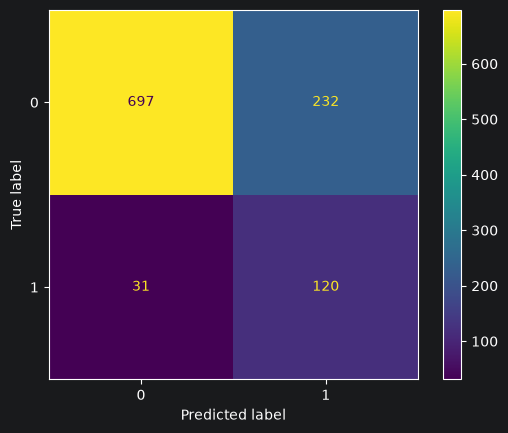

In [10]:
train_and_evaluate(classifier=RidgeClassifier, best_params=rgc0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [11]:
rgc50_best_params = grid_search(estimator=RidgeClassifier(), param_grid=rgc_params, cv=5, scoring='f1', X=X_train50, Y=Y_train)

Best params: {'alpha': 1000, 'class_weight': 'balanced'}
F1 score: 0.4740821130472848


,mean_test_score,params
13,0.474082,"{'alpha': 1000, 'class_weight': 'balanced'}"
1,0.468851,"{'alpha': 0.001, 'class_weight': 'balanced'}"
5,0.468851,"{'alpha': 0.1, 'class_weight': 'balanced'}"
3,0.468851,"{'alpha': 0.01, 'class_weight': 'balanced'}"
7,0.468497,"{'alpha': 1, 'class_weight': 'balanced'}"


Accuracy: 0.7537037037037037
F1 score: 0.4701195219123506
Precision: 0.33618233618233617
Recall: 0.7814569536423841


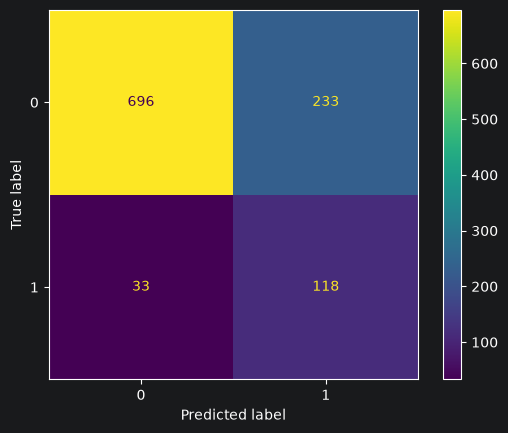

In [12]:
train_and_evaluate(classifier=RidgeClassifier, best_params=rgc50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)

# **LDA (Linear Discriminant Analysis)**

In [21]:
lda_params = [
    {
        'solver': ['svd'],
        'shrinkage': [None]
    },
    {
    'solver': ['lsqr', 'eigen'],
    'shrinkage': [None, 'auto', 0.1, 0.3, 0.5, 0.7]
    }
]

### PCA with 95% explained variance

In [22]:
lda95_best_params = grid_search(estimator=LinearDiscriminantAnalysis(), param_grid=lda_params, cv=5, scoring='f1', X=X_train95, Y=Y_train)

Best params: {'shrinkage': 0.7, 'solver': 'lsqr'}
F1 score: 0.43483499779278895


,mean_test_score,params
11,0.434835,"{'shrinkage': 0.7, 'solver': 'lsqr'}"
12,0.434835,"{'shrinkage': 0.7, 'solver': 'eigen'}"
9,0.419755,"{'shrinkage': 0.5, 'solver': 'lsqr'}"
10,0.419755,"{'shrinkage': 0.5, 'solver': 'eigen'}"
7,0.385173,"{'shrinkage': 0.3, 'solver': 'lsqr'}"


Accuracy: 0.8592592592592593
F1 score: 0.4899328859060403
Precision: 0.4965986394557823
Recall: 0.48344370860927155


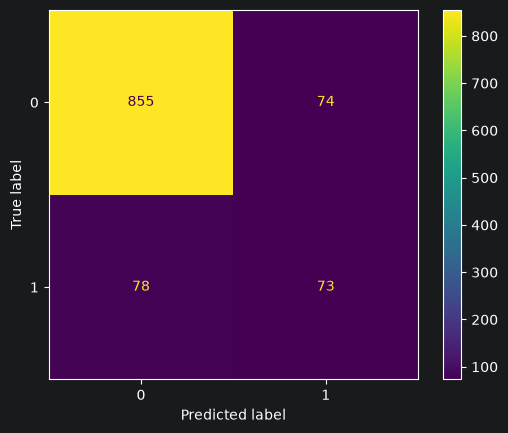

In [23]:
train_and_evaluate(classifier=LinearDiscriminantAnalysis, best_params=lda95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

### Without PCA

In [26]:
import warnings
from sklearn.exceptions import FitFailedWarning

warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# this is to get rid of warnings that occur when eigen solver cant fit all instances

In [27]:
lda0_best_params = grid_search(estimator=LinearDiscriminantAnalysis(), param_grid=lda_params, cv=5, scoring='f1', X=X_train0, Y=Y_train)

Best params: {'shrinkage': 0.7, 'solver': 'lsqr'}
F1 score: 0.45873281079568484


,mean_test_score,params
12,0.458733,"{'shrinkage': 0.7, 'solver': 'eigen'}"
11,0.458733,"{'shrinkage': 0.7, 'solver': 'lsqr'}"
10,0.441752,"{'shrinkage': 0.5, 'solver': 'eigen'}"
9,0.441752,"{'shrinkage': 0.5, 'solver': 'lsqr'}"
7,0.419290,"{'shrinkage': 0.3, 'solver': 'lsqr'}"


Accuracy: 0.8527777777777777
F1 score: 0.5077399380804953
Precision: 0.47674418604651164
Recall: 0.543046357615894


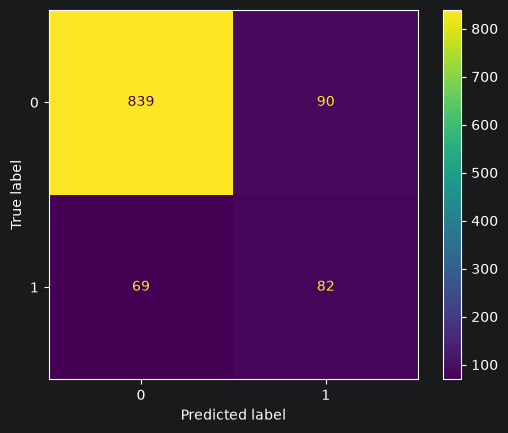

In [28]:
train_and_evaluate(classifier=LinearDiscriminantAnalysis, best_params=lda0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [29]:
lda50_best_params = grid_search(estimator=LinearDiscriminantAnalysis(), param_grid=lda_params, cv=5, scoring='f1', X=X_train50, Y=Y_train)

Best params: {'shrinkage': 0.7, 'solver': 'lsqr'}
F1 score: 0.40734248455100086


,mean_test_score,params
11,0.407342,"{'shrinkage': 0.7, 'solver': 'lsqr'}"
12,0.407342,"{'shrinkage': 0.7, 'solver': 'eigen'}"
9,0.393106,"{'shrinkage': 0.5, 'solver': 'lsqr'}"
10,0.393106,"{'shrinkage': 0.5, 'solver': 'eigen'}"
7,0.384187,"{'shrinkage': 0.3, 'solver': 'lsqr'}"


Accuracy: 0.8601851851851852
F1 score: 0.47017543859649125
Precision: 0.5
Recall: 0.44370860927152317


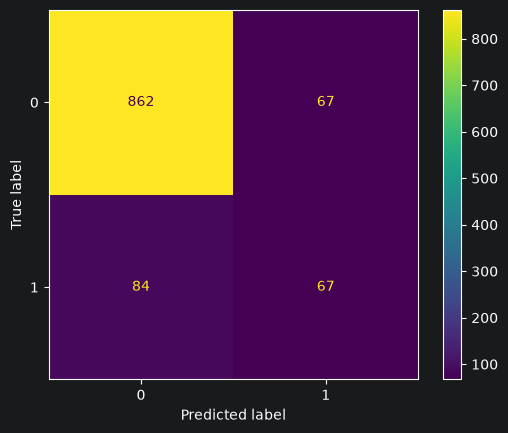

In [30]:
train_and_evaluate(classifier=LinearDiscriminantAnalysis, best_params=lda50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)

# Random Forest

In [48]:
rf_params = {
    "n_estimators": [100, 300, 500],
    "class_weight": [None, 'balanced', 'balanced_subsample'],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20, 40],
    "min_samples_leaf": [1, 2, 4, 10],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
    "criterion": ["gini", "entropy"]
}

# PCA with 95% explained variance

In [49]:
rf95_best_params = grid_search(estimator=RandomForestClassifier(), param_grid=rf_params, cv=5, scoring='f1', X=X_train95, Y=Y_train, randomized=True)

Best params: {'n_estimators': 300, 'min_samples_split': 40, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': True}
F1 score: 0.46064507063537086


,mean_test_score,params
41,0.460645,"{'n_estimators': 300, 'min_samples_split': 40,..."
22,0.457710,"{'n_estimators': 500, 'min_samples_split': 40,..."
39,0.432276,"{'n_estimators': 100, 'min_samples_split': 20,..."
10,0.384007,"{'n_estimators': 300, 'min_samples_split': 40,..."
26,0.337572,"{'n_estimators': 300, 'min_samples_split': 40,..."


Accuracy: 0.8212962962962963
F1 score: 0.49076517150395776
Precision: 0.40789473684210525
Recall: 0.6158940397350994


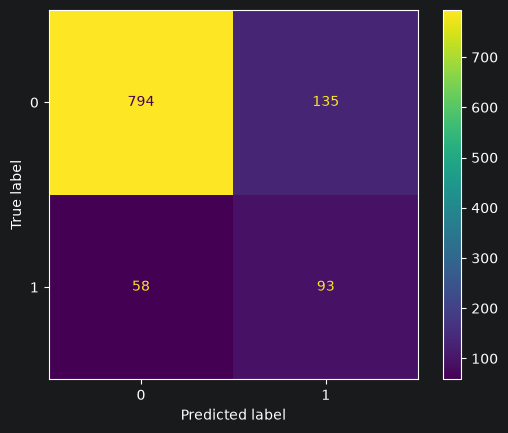

In [51]:
train_and_evaluate(classifier=RandomForestClassifier, best_params=rf95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

### Without PCA

In [52]:
rf0_best_params = grid_search(estimator=RandomForestClassifier(), param_grid=rf_params, cv=5, scoring='f1', X=X_train0, Y=Y_train, randomized=True)

Best params: {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': True}
F1 score: 0.49525867483064145


,mean_test_score,params
39,0.495259,"{'n_estimators': 100, 'min_samples_split': 20,..."
22,0.490454,"{'n_estimators': 500, 'min_samples_split': 40,..."
41,0.485438,"{'n_estimators': 300, 'min_samples_split': 40,..."
10,0.483870,"{'n_estimators': 300, 'min_samples_split': 40,..."
23,0.478455,"{'n_estimators': 300, 'min_samples_split': 20,..."


Accuracy: 0.8333333333333334
F1 score: 0.5054945054945055
Precision: 0.431924882629108
Recall: 0.609271523178808


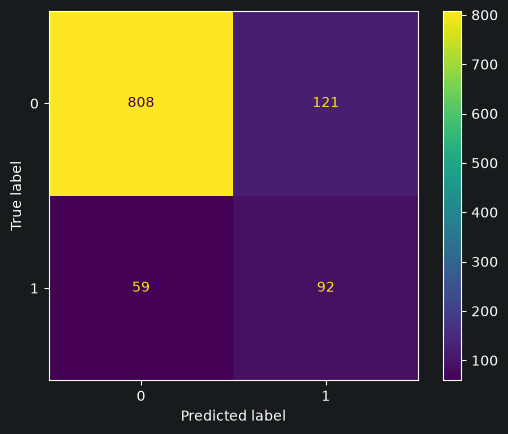

In [53]:
train_and_evaluate(classifier=RandomForestClassifier, best_params=rf0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [54]:
rf50_best_params = grid_search(estimator=RandomForestClassifier(), param_grid=rf_params, cv=5, scoring='f1', X=X_train50, Y=Y_train, randomized=True)

Best params: {'n_estimators': 300, 'min_samples_split': 40, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': True}
F1 score: 0.49889843802836503


,mean_test_score,params
41,0.498898,"{'n_estimators': 300, 'min_samples_split': 40,..."
22,0.481397,"{'n_estimators': 500, 'min_samples_split': 40,..."
39,0.465861,"{'n_estimators': 100, 'min_samples_split': 20,..."
10,0.456882,"{'n_estimators': 300, 'min_samples_split': 40,..."
26,0.450027,"{'n_estimators': 300, 'min_samples_split': 40,..."


Accuracy: 0.787962962962963
F1 score: 0.46867749419953597
Precision: 0.3607142857142857
Recall: 0.6688741721854304


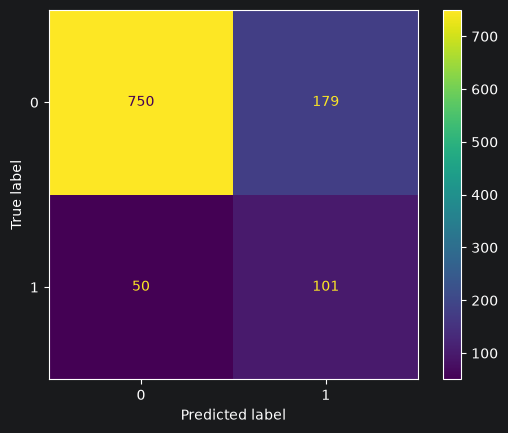

In [56]:
train_and_evaluate(classifier=RandomForestClassifier, best_params=rf50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)

# XGBoost